In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fraud_utils import DATA_DIR, reduce_memory_usage

pd.options.display.max_columns = 100
plt.rcParams["figure.figsize"] = (9, 4)
%matplotlib inline


In [2]:
train_txn = pd.read_csv(DATA_DIR / "train_transaction.csv")
train_id = pd.read_csv(DATA_DIR / "train_identity.csv")
test_txn = pd.read_csv(DATA_DIR / "test_transaction.csv")
test_id = pd.read_csv(DATA_DIR / "test_identity.csv")

for name, df in [("train_transaction", train_txn), ("train_identity", train_id),
                  ("test_transaction", test_txn), ("test_identity", test_id)]:
    print(f"{name:20s} shape={df.shape}")


train_transaction    shape=(590540, 394)
train_identity       shape=(144233, 41)
test_transaction     shape=(506691, 393)
test_identity        shape=(141907, 41)


In [5]:
train_txn_sample = train_txn.sample(n=100, random_state=42).reset_index(drop=True)
train_id_sample = train_id.sample(n=100, random_state=42).reset_index(drop=True)
test_txn_sample = test_txn.sample(n=100, random_state=42).reset_index(drop=True)
test_id_sample = test_id.sample(n=100, random_state=42).reset_index(drop=True)

print(f"train_txn_sample: {train_txn_sample.shape}")
print(f"train_id_sample: {train_id_sample.shape}")
print(f"test_txn_sample: {test_txn_sample.shape}")
print(f"test_id_sample: {test_id_sample.shape}")            




train_txn_sample: (100, 394)
train_id_sample: (100, 41)
test_txn_sample: (100, 393)
test_id_sample: (100, 41)


In [6]:
sample_dir = DATA_DIR / "sample"
sample_dir.mkdir(parents=True, exist_ok=True)


for name, df in [
    ("train_transaction_sample", train_txn_sample),
    ("train_identity_sample", train_id_sample),
    ("test_transaction_sample", test_txn_sample),
    ("test_identity_sample", test_id_sample),
]:
    out_path = sample_dir / f"{name}.csv"
    df.to_csv(out_path, index=False)
    print(f"Saved: {out_path}")

Saved: /Users/srimugunthan/Documents/gitrepos/Credit-card-fraud-GNN/ieee-fraud-detection/sample/train_transaction_sample.csv
Saved: /Users/srimugunthan/Documents/gitrepos/Credit-card-fraud-GNN/ieee-fraud-detection/sample/train_identity_sample.csv
Saved: /Users/srimugunthan/Documents/gitrepos/Credit-card-fraud-GNN/ieee-fraud-detection/sample/test_transaction_sample.csv
Saved: /Users/srimugunthan/Documents/gitrepos/Credit-card-fraud-GNN/ieee-fraud-detection/sample/test_identity_sample.csv


In [3]:
train_txn.info(memory_usage="deep")
train_txn = reduce_memory_usage(train_txn)
train_txn.info(memory_usage="deep")

train_id.info(memory_usage="deep")
train_id = reduce_memory_usage(train_id)
train_id.info(memory_usage="deep")

test_txn.info(memory_usage="deep")
test_txn = reduce_memory_usage(test_txn)
test_txn.info(memory_usage="deep")

test_id.info(memory_usage="deep")
test_id = reduce_memory_usage(test_id)
test_id.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float64(376), int64(4), object(14)
memory usage: 2.0 GB
  Memory: 2062.1 MB -> 1203.2 MB (42% reduction)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: float32(376), int16(1), int32(2), int8(1), object(14)
memory usage: 1.2 GB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64

In [4]:
cols = ["TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD",
    "P_emaildomain", "R_emaildomain", "dist1", "dist2", "addr1", "addr2"]

missing = train_txn[cols].isnull().sum().rename("missing_count")
missing_pct = (missing / len(train_txn) * 100).rename("missing_pct")

summary = pd.concat([missing, missing_pct], axis=1).sort_values(
    ["missing_count", "missing_pct"], ascending=False
)

print(summary)

                missing_count  missing_pct
dist2                  552913    93.628374
R_emaildomain          453249    76.751617
dist1                  352271    59.652352
P_emaildomain           94456    15.994852
addr1                   65706    11.126427
addr2                   65706    11.126427
TransactionID               0     0.000000
isFraud                     0     0.000000
TransactionDT               0     0.000000
TransactionAmt              0     0.000000
ProductCD                   0     0.000000


In [5]:
group_map = {
    "C": [f"C{i}" for i in range(1, 15)],
    "D": [f"D{i}" for i in range(1, 16)],
    "M": [f"M{i}" for i in range(1, 10)],
    "V": [f"V{i}" for i in range(1, 340)],
    "card": [f"card{i}" for i in range(1, 7)],
}

rows = []
for group_name, cols in group_map.items():
    cols = [c for c in cols if c in train_txn.columns]
    if not cols:
        continue

    missing_count = train_txn[cols].isnull().sum().sum()
    total_cells = train_txn[cols].size
    missing_pct = (missing_count / total_cells) * 100

    rows.append({
        "group": group_name,
        "columns": len(cols),
        "missing_count": missing_count,
        "total_cells": total_cells,
        "missing_pct": missing_pct,
    })

group_missing = pd.DataFrame(rows).sort_values("missing_pct", ascending=False)
group_missing["missing_pct"] = group_missing["missing_pct"].map(lambda x: f"{x:.2f}%")

print(group_missing[["group", "columns", "missing_count", "total_cells", "missing_pct"]])

  group  columns  missing_count  total_cells missing_pct
1     D       15        5151097      8858100      58.15%
2     M        9        2653355      5314860      49.92%
3     V      339       86160028    200193060      43.04%
4  card        6          17905      3543240       0.51%
0     C       14              0      8267560       0.00%


In [6]:
identity_group_map = {
    "TransactionID": ["TransactionID"],
    "id_01_to_id_38": [f"id_{i:02d}" for i in range(1, 39)],
    "DeviceType": ["DeviceType"],
    "DeviceInfo": ["DeviceInfo"],
}

identity_rows = []
for group_name, cols in identity_group_map.items():
    cols = [c for c in cols if c in train_id.columns]
    if not cols:
        continue

    missing_count = train_id[cols].isnull().sum().sum()
    total_cells = train_id[cols].size
    missing_pct = (missing_count / total_cells) * 100

    identity_rows.append({
        "group": group_name,
        "columns": len(cols),
        "missing_count": missing_count,
        "total_cells": total_cells,
        "missing_pct": missing_pct,
    })

identity_group_missing = pd.DataFrame(identity_rows).sort_values("missing_pct", ascending=False)
identity_group_missing["missing_pct"] = identity_group_missing["missing_pct"].map(lambda x: f"{x:.2f}%")

print("train_identity column groups missingness:")
print(identity_group_missing[["group", "columns", "missing_count", "total_cells", "missing_pct"]])

id_cols = [f"id_{i:02d}" for i in range(1, 39)]
id_missing = train_id[id_cols].isnull().sum().rename("missing_count")
id_missing_pct = (id_missing / len(train_id) * 100).rename("missing_pct")
id_summary = pd.concat([id_missing, id_missing_pct], axis=1).sort_values(
    ["missing_count", "missing_pct"], ascending=False
)

print("\nTop missing identity attributes:")
print(id_summary.head(15))

device_missing = pd.concat(
    [
        train_id[["DeviceType", "DeviceInfo"]].isnull().sum().rename("missing_count"),
        (train_id[["DeviceType", "DeviceInfo"]].isnull().mean() * 100).rename("missing_pct")
    ],
    axis=1
).sort_values(["missing_count", "missing_pct"], ascending=False)

print("\nDevice metadata missingness:")
print(device_missing)

train_identity column groups missingness:
            group  columns  missing_count  total_cells missing_pct
1  id_01_to_id_38       38        2075117      5480854      37.86%
3      DeviceInfo        1          25567       144233      17.73%
2      DeviceType        1           3423       144233       2.37%
0   TransactionID        1              0       144233       0.00%

Top missing identity attributes:
       missing_count  missing_pct
id_24         139486    96.708798
id_25         139101    96.441868
id_07         139078    96.425922
id_08         139078    96.425922
id_21         139074    96.423149
id_26         139070    96.420375
id_22         139064    96.416215
id_23         139064    96.416215
id_27         139064    96.416215
id_18          99120    68.722137
id_03          77909    54.016071
id_04          77909    54.016071
id_33          70944    49.187079
id_09          69307    48.052110
id_10          69307    48.052110

Device metadata missingness:
            mis

isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud rate: 3.4990%  (20,663 fraud / 590,540 total)


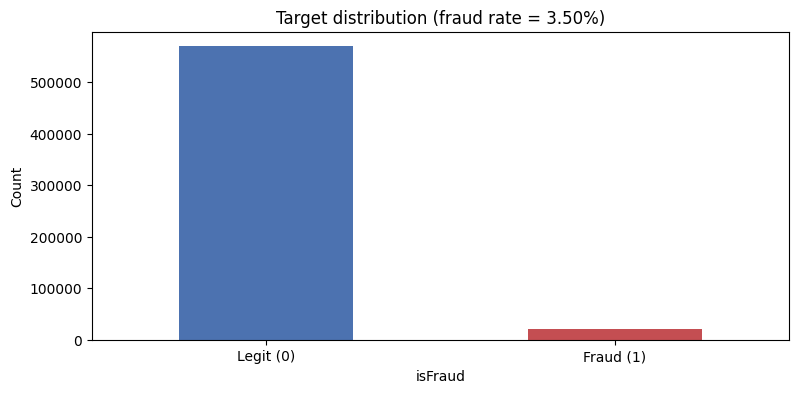

In [8]:
fraud_counts = train_txn["isFraud"].value_counts()
fraud_rate = train_txn["isFraud"].mean()
print(fraud_counts)
print(f"\nFraud rate: {fraud_rate:.4%}  ({fraud_counts[1]:,} fraud / {len(train_txn):,} total)")

fig, ax = plt.subplots()
fraud_counts.sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legit (0)", "Fraud (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title(f"Target distribution (fraud rate = {fraud_rate:.2%})")
plt.show()


count    590540.000000
mean        135.027161
std         239.162521
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64


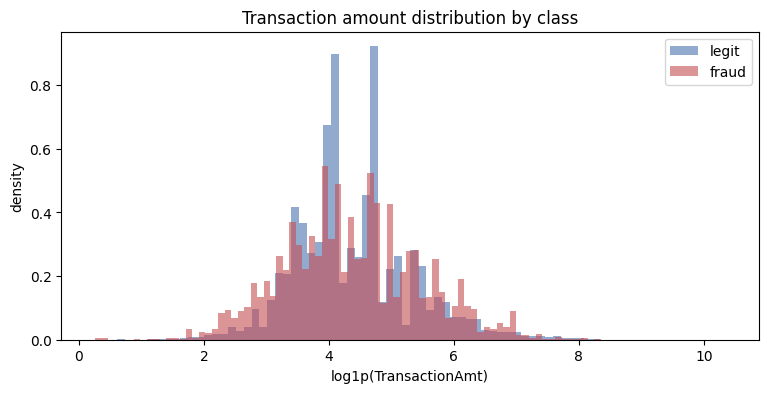

is_round_amount
0    0.034256
1    0.035677
Name: fraud_rate, dtype: float64


In [10]:
print(train_txn["TransactionAmt"].describe())

fig, ax = plt.subplots()
ax.hist(np.log1p(train_txn.loc[train_txn.isFraud == 0, "TransactionAmt"]), bins=80, alpha=0.6,
        label="legit", density=True, color="#4C72B0")
ax.hist(np.log1p(train_txn.loc[train_txn.isFraud == 1, "TransactionAmt"]), bins=80, alpha=0.6,
        label="fraud", density=True, color="#C44E52")
ax.set_xlabel("log1p(TransactionAmt)")
ax.set_ylabel("density")
ax.set_title("Transaction amount distribution by class")
ax.legend()
plt.show()

# "Round dollar" amounts (no cents) are a classic weak fraud signal
decimal = train_txn["TransactionAmt"] - train_txn["TransactionAmt"].astype(int)
is_round = (decimal == 0).astype(int)
print(train_txn.groupby(is_round)["isFraud"].mean().rename_axis("is_round_amount").rename("fraud_rate"))


/var/folders/lf/hsp4mkf14lv1k1qxwbvz70y00000gn/T/ipykernel_70527/275877953.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Transaction_day"] = (df["TransactionDT"] / (3600 * 24)).astype(int)
/var/folders/lf/hsp4mkf14lv1k1qxwbvz70y00000gn/T/ipykernel_70527/275877953.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Transaction_hour"] = ((df["TransactionDT"] / 3600) % 24).astype(int)
/var/folders/lf/hsp4mkf14lv1k1qxwbvz70y00000gn/T/ipykernel_70527/275877953.py:4: PerformanceWarning: DataFrame is highly fragmented.  T

train day range: 1-182 (181 days)
test  day range: 213-395 (182 days)
-> test is entirely AFTER train in time, hence the time-based split used later.


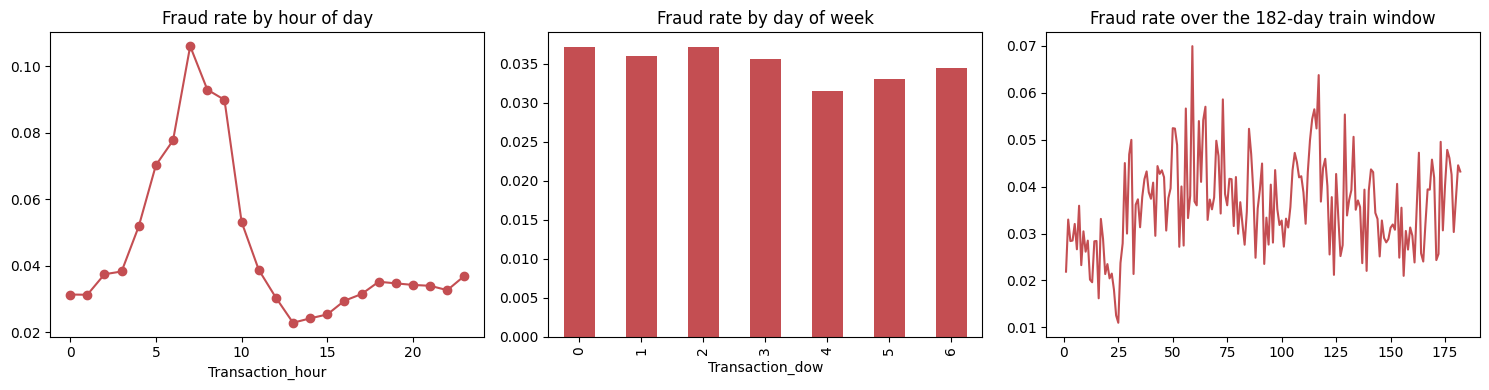

In [11]:
for df in (train_txn, test_txn):
    df["Transaction_day"] = (df["TransactionDT"] / (3600 * 24)).astype(int)
    df["Transaction_hour"] = ((df["TransactionDT"] / 3600) % 24).astype(int)
    df["Transaction_dow"] = df["Transaction_day"] % 7

print(f"train day range: {train_txn.Transaction_day.min()}-{train_txn.Transaction_day.max()} "
      f"({train_txn.Transaction_day.max() - train_txn.Transaction_day.min()} days)")
print(f"test  day range: {test_txn.Transaction_day.min()}-{test_txn.Transaction_day.max()} "
      f"({test_txn.Transaction_day.max() - test_txn.Transaction_day.min()} days)")
print("-> test is entirely AFTER train in time, hence the time-based split used later.")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
train_txn.groupby("Transaction_hour")["isFraud"].mean().plot(ax=axes[0], marker="o", color="#C44E52")
axes[0].set_title("Fraud rate by hour of day")
train_txn.groupby("Transaction_dow")["isFraud"].mean().plot(ax=axes[1], kind="bar", color="#C44E52")
axes[1].set_title("Fraud rate by day of week")
daily = train_txn.groupby("Transaction_day")["isFraud"].agg(["mean", "count"])
axes[2].plot(daily.index, daily["mean"], color="#C44E52")
axes[2].set_title("Fraud rate over the 182-day train window")
plt.tight_layout()
plt.show()


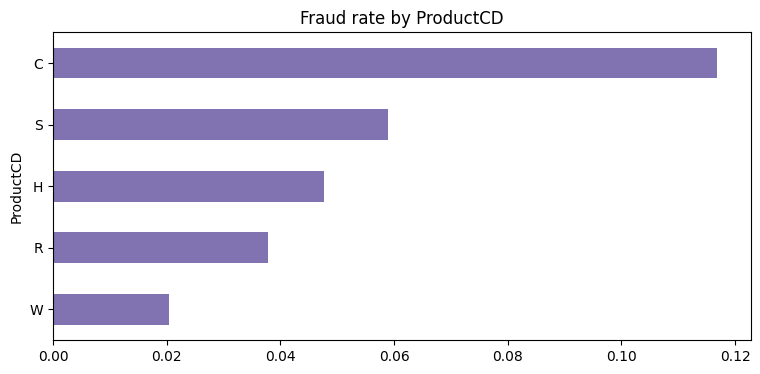

card1    unique= 13,553  null_rate=0.000
card2    unique=    500  null_rate=0.015
card3    unique=    114  null_rate=0.003
card4    unique=      4  null_rate=0.003
card5    unique=    119  null_rate=0.007
card6    unique=      4  null_rate=0.003


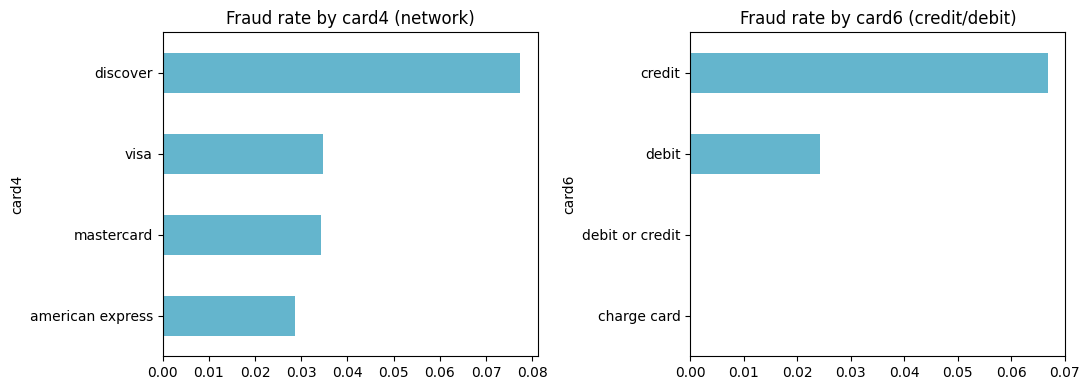

In [12]:
fig, ax = plt.subplots()
train_txn.groupby("ProductCD")["isFraud"].mean().sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Fraud rate by ProductCD")
plt.show()

for col in ["card1", "card2", "card3", "card4", "card5", "card6"]:
    print(f"{col:8s} unique={train_txn[col].nunique():7,d}  null_rate={train_txn[col].isnull().mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train_txn.groupby("card4")["isFraud"].mean().sort_values().plot(kind="barh", ax=axes[0], color="#64B5CD")
axes[0].set_title("Fraud rate by card4 (network)")
train_txn.groupby("card6")["isFraud"].mean().sort_values().plot(kind="barh", ax=axes[1], color="#64B5CD")
axes[1].set_title("Fraud rate by card6 (credit/debit)")
plt.tight_layout()
plt.show()


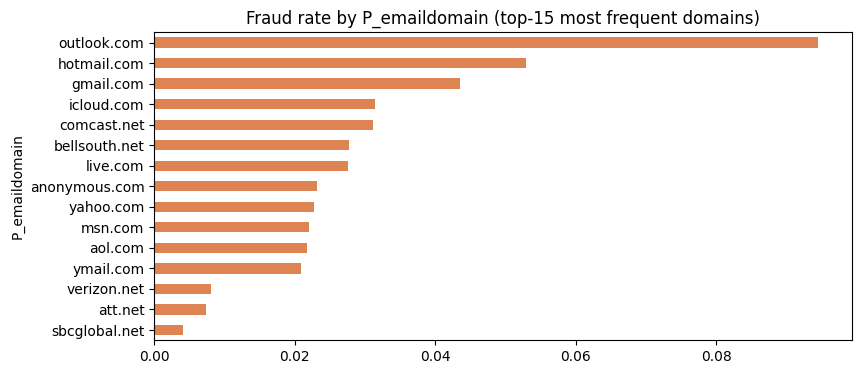

P_equals_R_emaildomain
0    0.022070
1    0.096504
Name: fraud_rate, dtype: float64


In [13]:
top_p_domains = train_txn["P_emaildomain"].value_counts().head(15).index
domain_fraud = train_txn[train_txn["P_emaildomain"].isin(top_p_domains)].groupby("P_emaildomain")["isFraud"].mean()
domain_fraud.sort_values().plot(kind="barh", color="#DD8452")
plt.title("Fraud rate by P_emaildomain (top-15 most frequent domains)")
plt.show()

email_match = (train_txn["P_emaildomain"] == train_txn["R_emaildomain"]).astype(int)
print(train_txn.groupby(email_match)["isFraud"].mean().rename_axis("P_equals_R_emaildomain").rename("fraud_rate"))


In [8]:
train_id_ids = set(train_id["TransactionID"])
train_txn_ids = set(train_txn["TransactionID"])

common_ids = train_id_ids & train_txn_ids

print(f"train_id unique TransactionIDs: {len(train_id_ids):,}")
print(f"train_txn unique TransactionIDs: {len(train_txn_ids):,}")
print(f"Common TransactionIDs: {len(common_ids):,}")
print(f"Common ratio in train_id: {len(common_ids) / len(train_id_ids):.2%}")
print(f"Common ratio in train_txn: {len(common_ids) / len(train_txn_ids):.2%}")

train_id unique TransactionIDs: 144,233
train_txn unique TransactionIDs: 590,540
Common TransactionIDs: 144,233
Common ratio in train_id: 100.00%
Common ratio in train_txn: 24.42%


In [9]:
# Add the target label from the transaction table to each identity row
train_id = train_id.merge(
    train_txn[["TransactionID", "isFraud"]],
    on="TransactionID",
    how="left"
)

print(f"train_id shape: {train_id.shape}")
print(train_id[["TransactionID", "isFraud"]].head())

train_id shape: (144233, 42)
   TransactionID  isFraud
0        2987004        0
1        2987008        0
2        2987010        0
3        2987011        0
4        2987016        0


Transactions with identity data: 100.00%
has_identity
True    0.07847
Name: fraud_rate, dtype: float64


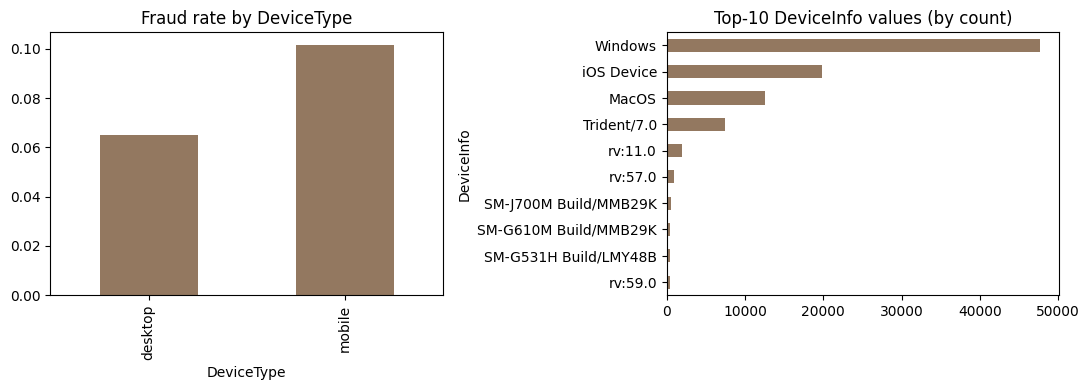

In [10]:
has_identity = train_id["id_01"].notnull()  # any id_ column works as a coverage proxy
print(f"Transactions with identity data: {has_identity.mean():.2%}")
print(train_id.groupby(has_identity)["isFraud"].mean().rename_axis("has_identity").rename("fraud_rate"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
train_id.groupby("DeviceType")["isFraud"].mean().plot(kind="bar", ax=axes[0], color="#937860")
axes[0].set_title("Fraud rate by DeviceType")
train_id["DeviceInfo"].value_counts().head(10).plot(kind="barh", ax=axes[1], color="#937860")
axes[1].invert_yaxis()
axes[1].set_title("Top-10 DeviceInfo values (by count)")
plt.tight_layout()
plt.show()


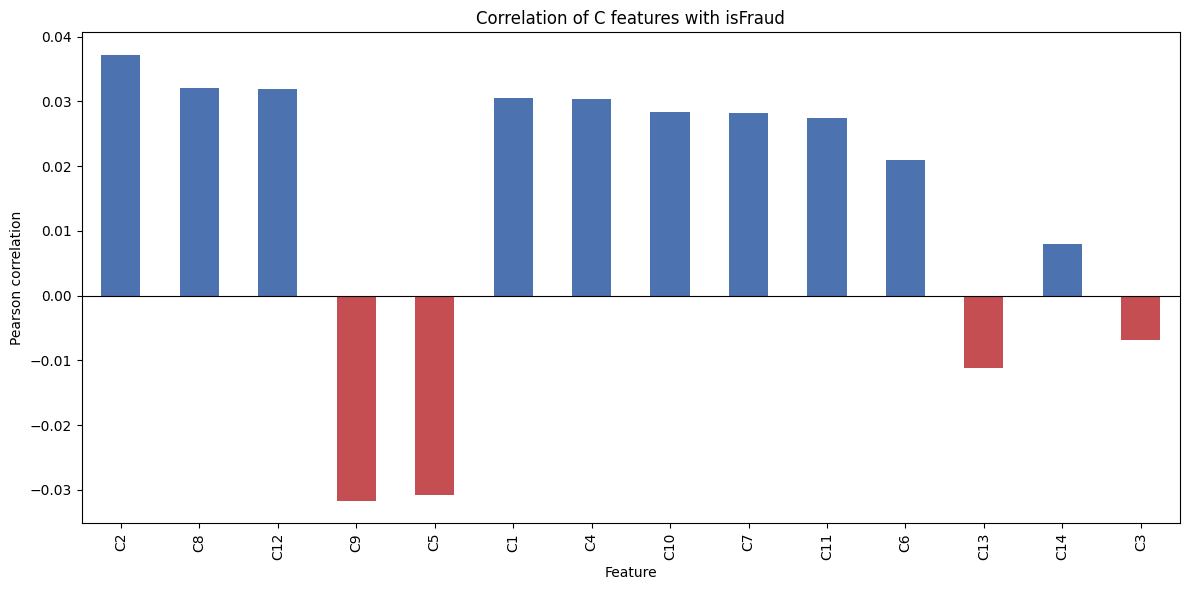

In [11]:
c_cols = [c for c in train_txn.columns if c.startswith("C") and c[1:].isdigit()]

corr = (
    train_txn[c_cols + ["isFraud"]]
    .corr(numeric_only=True)
    .loc[c_cols, "isFraud"]
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
corr.plot(kind="bar", color=["#4C72B0" if x >= 0 else "#C44E52" for x in corr], ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of C features with isFraud")
ax.set_xlabel("Feature")
ax.set_ylabel("Pearson correlation")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

In [18]:
corr_table = corr.to_frame(name="pearson_correlation").reset_index().rename(columns={"index": "feature"})
corr_table["abs_correlation"] = corr_table["pearson_correlation"].abs()
corr_table = corr_table.sort_values("abs_correlation", ascending=False)[
    ["feature", "pearson_correlation", "abs_correlation"]
].reset_index(drop=True)

display(corr_table)

,feature,pearson_correlation,abs_correlation
0,C2,0.037229,0.037229
1,C8,0.032139,0.032139
2,C12,0.031905,0.031905
3,C9,-0.031703,0.031703
4,C5,-0.030754,0.030754
5,C1,0.030570,0.030570
6,C4,0.030382,0.030382
7,C10,0.028396,0.028396
8,C7,0.028160,0.028160
9,C11,0.027484,0.027484


In [19]:
import ppscore as pps



counting_features = [c for c in train_txn.columns if c.startswith("C") and c[1:].isdigit()]
counting_df = train_txn[counting_features + ["isFraud"]].copy()

# Predictive Power Score for each counting-like feature vs. isFraud
pps_df = pps.predictors(counting_df, y="isFraud")
pps_df = pps_df[["x", "ppscore"]].sort_values("ppscore", ascending=False)

print(pps_df.head(25))



      x  ppscore
0    C1        0
1    C2        0
2    C3        0
3    C4        0
4    C5        0
5    C6        0
6    C7        0
7    C8        0
8    C9        0
9   C10        0
10  C11        0
11  C12        0
12  C13        0
13  C14        0


339 V-columns total; 180 have <50% missing

Top-20 V-columns by variance:
V307    1.928960e+07
V127    1.796630e+07
V317    1.584074e+07
V133    1.441202e+07
V308    9.132026e+06
V128    9.061658e+06
V318    7.802768e+06
V134    7.689456e+06
V306    5.517094e+06
V126    5.508182e+06
V316    5.153050e+06
V132    5.135237e+06
V320    2.242016e+05
V136    2.041308e+05
V321    1.459646e+05
V310    1.245971e+05
V137    1.213357e+05
V319    1.104265e+05
V130    9.983103e+04
V135    8.634639e+04
dtype: float32
--
V310    0.011071
V307    0.005948
V317    0.005010
V320    0.004961
V132   -0.004263
V126   -0.003546
V134   -0.003512
V308    0.003253
V133   -0.003165
V130    0.003076
V316   -0.002960
V127   -0.002629
V128   -0.001930
V306   -0.001863
V321    0.001677
V318    0.000997
V135   -0.000276
V137   -0.000115
V319    0.000061
V136   -0.000042
Name: isFraud, dtype: float64


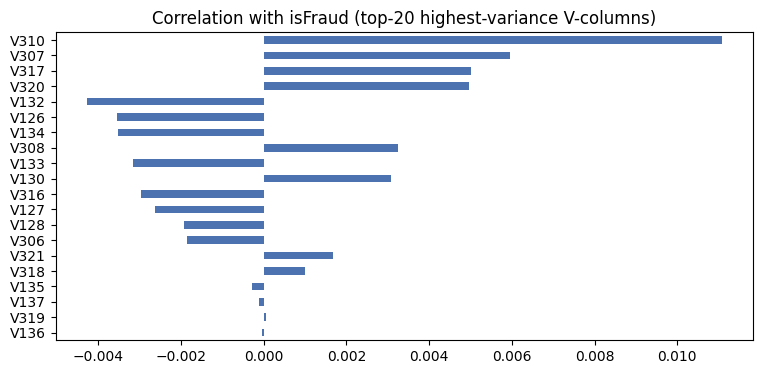

In [27]:
v_cols = [c for c in train_txn.columns if c.startswith("V") and c[1:].isdigit()]
v_null_rate = train_txn[v_cols].isnull().mean()
print(f"{len(v_cols)} V-columns total; {sum(v_null_rate < 0.5)} have <50% missing")

v_keep_candidates = v_null_rate[v_null_rate < 0.5].index
v_variance = train_txn[v_keep_candidates].var().sort_values(ascending=False)
top20_v = v_variance.head(20)
print("\nTop-20 V-columns by variance:")
print(top20_v)

corrs = train_txn[top20_v.index.tolist() + ["isFraud"]].corr()["isFraud"].drop("isFraud").sort_values(key=abs, ascending=False)
print("--")
print(corrs)
corrs.plot(kind="barh", color="#4C72B0")
plt.title("Correlation with isFraud (top-20 highest-variance V-columns)")
plt.gca().invert_yaxis()
plt.show()

Reduced to 92 principal components
Explained variance retained: 0.9507
Validation ROC-AUC using PCA features: 0.8209

Top PCs by absolute correlation with isFraud:
PC2     0.2139
PC4     0.1417
PC3     0.1401
PC6     0.0951
PC8     0.0828
PC39    0.0769
PC20    0.0619
PC12    0.0593
PC5     0.0589
PC10    0.0512
dtype: float64


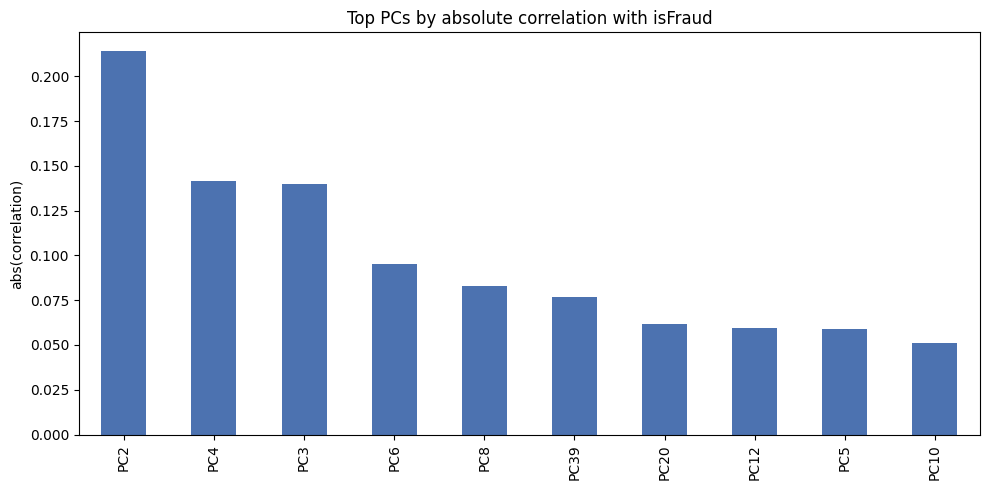

In [28]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Use the V features already present in the notebook
X = train_txn[v_cols].copy()
y = train_txn["isFraud"]

# Median imputation + standardization for PCA
imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# Dimensionality reduction
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Reduced to {X_pca.shape[1]} principal components")
print(f"Explained variance retained: {pca.explained_variance_ratio_.sum():.4f}")

# Check whether the reduced representation carries signal for isFraud
X_train, X_val, y_train, y_val = train_test_split(
    X_pca, y, test_size=0.25, stratify=y, random_state=42
)

clf = LogisticRegression(max_iter=2000, class_weight="balanced", solver="liblinear")
clf.fit(X_train, y_train)

val_proba = clf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, val_proba)

print(f"Validation ROC-AUC using PCA features: {auc:.4f}")

# Inspect which PCs are most associated with the label
pc_corr = pd.Series(
    [np.corrcoef(X_pca[:, i], y)[0, 1] for i in range(X_pca.shape[1])],
    index=[f"PC{i+1}" for i in range(X_pca.shape[1])]
)
top_pc_signal = pc_corr.abs().sort_values(ascending=False).head(10)

print("\nTop PCs by absolute correlation with isFraud:")
print(top_pc_signal.round(4))

# Optional: visualize PCA signal
plt.figure(figsize=(10, 5))
top_pc_signal.plot(kind="bar", color="#4C72B0")
plt.title("Top PCs by absolute correlation with isFraud")
plt.ylabel("abs(correlation)")
plt.tight_layout()
plt.show()

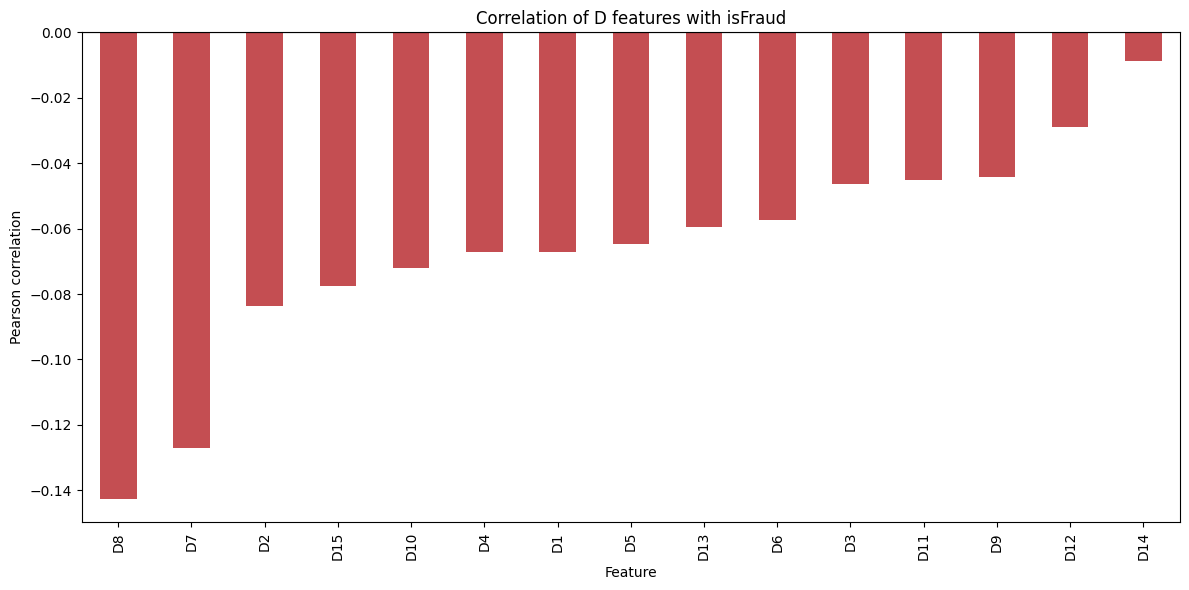

In [29]:
d_cols = [c for c in train_txn.columns if c.startswith("D") and c[1:].isdigit()]

corr = (
    train_txn[d_cols + ["isFraud"]]
    .corr(numeric_only=True)
    .loc[d_cols, "isFraud"]
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
corr.plot(kind="bar", color=["#4C72B0" if x >= 0 else "#C44E52" for x in corr], ax=ax)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Correlation of D features with isFraud")
ax.set_xlabel("Feature")
ax.set_ylabel("Pearson correlation")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

In [45]:
# Rebuild from the current DataFrame state
id_num_cols = [c for c in train_id.columns if c.startswith("id_")]
id_numeric_cols = [c for c in id_num_cols if pd.api.types.is_numeric_dtype(train_id[c])]
print(f"Numeric id_ columns: {id_numeric_cols}")

# optional safety check
missing = [c for c in id_numeric_cols + ["isFraud"] if c not in train_id.columns]
if missing:
    raise ValueError(f"Missing columns in train_id: {missing}")

corr = (
    train_id[id_numeric_cols + ["isFraud"]]
    .corr(numeric_only=True)
    .loc[id_numeric_cols, "isFraud"]
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

corr_table = (
    corr.to_frame(name="pearson_correlation")
    .reset_index()
    .rename(columns={"index": "feature"})
)
corr_table["abs_correlation"] = corr_table["pearson_correlation"].abs()
corr_table = corr_table.sort_values("abs_correlation", ascending=False)[
    ["feature", "pearson_correlation", "abs_correlation"]
].reset_index(drop=True)

display(corr_table)

Numeric id_ columns: ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06', 'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_13', 'id_14', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_24', 'id_25', 'id_26', 'id_32']


,feature,pearson_correlation,abs_correlation
0,id_17,0.150100,0.150100
1,id_01,-0.120099,0.120099
2,id_22,0.118409,0.118409
3,id_26,0.099587,0.099587
4,id_07,-0.084768,0.084768
5,id_32,0.069702,0.069702
6,id_21,0.063544,0.063544
7,id_20,0.061597,0.061597
8,id_04,-0.059701,0.059701
9,id_08,-0.057489,0.057489


M columns: ['M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']

Pearson correlations (or mapped boolean correlations) with isFraud:
         pearson_corr mapped
feature                     
M3          -0.038697   True
M2          -0.037091   True
M9          -0.032055   True
M5           0.031802   True
M6          -0.023282   True
M8          -0.019067   True
M7           0.006831   True
M1           0.001259   True
M4                NaN   None


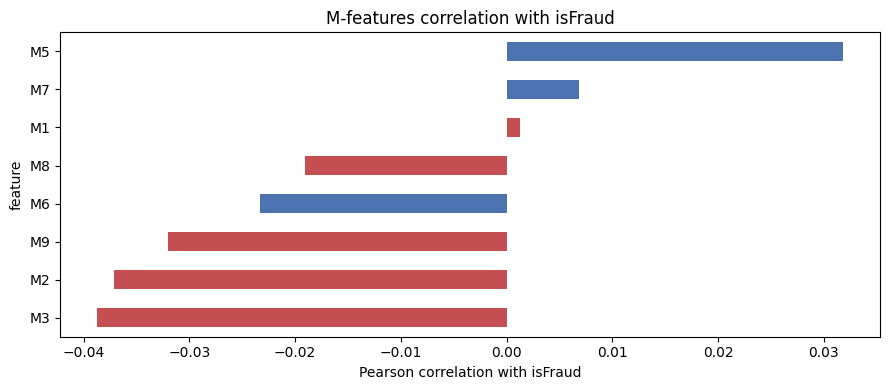


Category-level fraud rates for M4 (top categories):


,fraud_rate,n
M4,,
M0,0.036649,196405
M2,0.113739,59865
M1,0.027051,52826


In [46]:
# Correlation analysis between M1-M9 and isFraud
m_cols = [c for c in train_txn.columns if c.startswith("M") and c[1:].isdigit()]
print("M columns:", m_cols)

map_bool = {"T": 1, "Y": 1, True: 1, "F": 0, "N": 0, False: 0}

rows = []
cat_reports = {}

for col in m_cols:
    s = train_txn[col]
    if pd.api.types.is_numeric_dtype(s):
        corr = s.corr(train_txn["isFraud"])
        rows.append({"feature": col, "pearson_corr": corr, "mapped": False})
    else:
        s_mapped = s.map(map_bool)
        if s_mapped.notna().sum() and s_mapped.nunique(dropna=True) > 1:
            corr = s_mapped.corr(train_txn["isFraud"])
            rows.append({"feature": col, "pearson_corr": corr, "mapped": True})
        else:
            rows.append({"feature": col, "pearson_corr": np.nan, "mapped": None})
            # category-level fraud rates for non-numeric categorical columns
            grp = (
                train_txn[[col, "isFraud"]]
                .groupby(col)["isFraud"]
                .agg(["mean", "count"])
                .rename(columns={"mean": "fraud_rate", "count": "n"})
                .sort_values("n", ascending=False)
            )
            cat_reports[col] = grp

corr_df = pd.DataFrame(rows).set_index("feature")
corr_df["abs_corr"] = corr_df["pearson_corr"].abs()
corr_df = corr_df.sort_values("abs_corr", ascending=False)
print("\nPearson correlations (or mapped boolean correlations) with isFraud:")
print(corr_df[["pearson_corr", "mapped"]])

# plot correlations for numeric/mapped features
plot_df = corr_df[corr_df["pearson_corr"].notna()]["pearson_corr"]
if not plot_df.empty:
    ax = plot_df.sort_values().plot(kind="barh", color=["#4C72B0" if x>=0 else "#C44E52" for x in plot_df])
    ax.set_xlabel("Pearson correlation with isFraud")
    ax.set_title("M-features correlation with isFraud")
    plt.tight_layout()
    plt.show()

# Print category-level reports for non-numeric columns
if cat_reports:
    for col, grp in cat_reports.items():
        print(f"\nCategory-level fraud rates for {col} (top categories):")
        display(grp.head(10))